ResNet-18 Baseline — Deepfake Detection


## 1. Setup

In [ ]:
%%writefile download.py
#!/usr/bin/env python
""" Downloads FaceForensics++ """
import argparse
import os
import urllib
import urllib.request
import tempfile
import time
import sys
import json
from tqdm import tqdm
from os.path import join

FILELIST_URL = 'misc/filelist.json'
DEEPFEAKES_DETECTION_URL = 'misc/deepfake_detection_filenames.json'
DEEPFAKES_MODEL_NAMES = ['decoder_A.h5', 'decoder_B.h5', 'encoder.h5']

DATASETS = {
    'original': 'original_sequences/youtube',
    'DeepFakeDetection_original': 'original_sequences/actors',
    'Deepfakes': 'manipulated_sequences/Deepfakes',
    'DeepFakeDetection': 'manipulated_sequences/DeepFakeDetection',
    'Face2Face': 'manipulated_sequences/Face2Face',
    'FaceSwap': 'manipulated_sequences/FaceSwap',
    'NeuralTextures': 'manipulated_sequences/NeuralTextures'
}
ALL_DATASETS = list(DATASETS.keys())
COMPRESSION = ['raw', 'c23', 'c40']
TYPE = ['videos', 'masks', 'models']
SERVERS = ['EU', 'EU2', 'CA']


def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument('output_path', type=str)
    parser.add_argument('-d', '--dataset', type=str, default='all',
                        choices=list(DATASETS.keys()) + ['all'])
    parser.add_argument('-c', '--compression', type=str, default='raw',
                        choices=COMPRESSION)
    parser.add_argument('-t', '--type', type=str, default='videos',
                        choices=TYPE)
    parser.add_argument('-n', '--num_videos', type=int, default=None)
    parser.add_argument('--server', type=str, default='EU', choices=SERVERS)
    args = parser.parse_args()

    if args.server == 'EU':
        server_url = 'http://canis.vc.in.tum.de:8100/'
    elif args.server == 'EU2':
        server_url = 'http://kaldir.vc.in.tum.de/faceforensics/'
    else:
        server_url = 'http://falas.cmpt.sfu.ca:8100/'

    args.tos_url = server_url + 'webpage/FaceForensics_TOS.pdf'
    args.base_url = server_url + 'v3/'
    args.deepfakes_model_url = server_url + 'v3/manipulated_sequences/Deepfakes/models/'
    return args


def download_files(filenames, base_url, output_path, report_progress=True):
    os.makedirs(output_path, exist_ok=True)
    if report_progress:
        filenames = tqdm(filenames)
    for filename in filenames:
        download_file(base_url + filename, join(output_path, filename))


def reporthook(count, block_size, total_size):
    global start_time
    if count == 0:
        start_time = time.time()
        return
    duration = time.time() - start_time
    progress_size = int(count * block_size)
    speed = int(progress_size / (1024 * duration))
    percent = int(count * block_size * 100 / total_size)
    sys.stdout.write("\rProgress: %d%%, %d MB, %d KB/s, %d seconds passed" %
                     (percent, progress_size / (1024 * 1024), speed, duration))
    sys.stdout.flush()


def download_file(url, out_file, report_progress=False):
    out_dir = os.path.dirname(out_file)
    if not os.path.isfile(out_file):
        fh, out_file_tmp = tempfile.mkstemp(dir=out_dir)
        f = os.fdopen(fh, 'w')
        f.close()
        if report_progress:
            urllib.request.urlretrieve(url, out_file_tmp, reporthook=reporthook)
        else:
            urllib.request.urlretrieve(url, out_file_tmp)
        os.rename(out_file_tmp, out_file)
    else:
        tqdm.write('WARNING: skipping existing file ' + out_file)


def main(args):
    print('By pressing any key you confirm agreement to FaceForensics TOS:')
    print(args.tos_url)
    print('***')
    print('Press any key to continue, or CTRL-C to exit.')
    _ = input('')

    c_datasets = [args.dataset] if args.dataset != 'all' else ALL_DATASETS
    c_type = args.type
    c_compression = args.compression
    num_videos = args.num_videos
    output_path = args.output_path
    os.makedirs(output_path, exist_ok=True)

    for dataset in c_datasets:
        dataset_path = DATASETS[dataset]
        print(f'Downloading {c_type} of dataset "{dataset_path}"')

        if 'DeepFakeDetection' in dataset_path or 'actors' in dataset_path:
            filepaths = json.loads(urllib.request.urlopen(
                args.base_url + '/' + DEEPFEAKES_DETECTION_URL).read().decode("utf-8"))
            filelist = filepaths['actors'] if 'actors' in dataset_path else filepaths['DeepFakesDetection']
        elif 'original' in dataset_path:
            file_pairs = json.loads(urllib.request.urlopen(
                args.base_url + '/' + FILELIST_URL).read().decode("utf-8"))
            filelist = []
            for pair in file_pairs:
                filelist += pair
        else:
            file_pairs = json.loads(urllib.request.urlopen(
                args.base_url + '/' + FILELIST_URL).read().decode("utf-8"))
            filelist = []
            for pair in file_pairs:
                filelist.append('_'.join(pair))
                if c_type != 'models':
                    filelist.append('_'.join(pair[::-1]))

        if num_videos is not None and num_videos > 0:
            print(f'Downloading the first {num_videos} videos')
            filelist = filelist[:num_videos]

        dataset_videos_url = args.base_url + '{}/{}/{}/'.format(
            dataset_path, c_compression, c_type)

        if c_type == 'videos':
            dataset_output_path = join(output_path, dataset_path, c_compression, c_type)
            print(f'Output path: {dataset_output_path}')
            filelist = [filename + '.mp4' for filename in filelist]
            download_files(filelist, dataset_videos_url, dataset_output_path)


if __name__ == "__main__":
    args = parse_args()
    main(args)

Overwriting download.py


In [ ]:
import os

OUTPUT_BASE = '/content/FF_data'
NUM_VIDEOS  = 10
COMPRESSION = 'c40'
SERVER      = 'EU2'

categories = {
    'original':                  f'{OUTPUT_BASE}/real',
    'Deepfakes':                 f'{OUTPUT_BASE}/fake',
    'DeepFakeDetection_original': f'{OUTPUT_BASE}/DFD_real',
    'DeepFakeDetection':         f'{OUTPUT_BASE}/DFD_fake',
    'Face2Face':                 f'{OUTPUT_BASE}/Face2Face',
    'FaceSwap':                  f'{OUTPUT_BASE}/FaceSwap',
    'NeuralTextures':            f'{OUTPUT_BASE}/NeuralTextures',
}

for dataset, output_dir in categories.items():
    print(f'\n--- Downloading: {dataset} ---')
    os.system(
        f'echo "" | python download.py {output_dir} '
        f'-d {dataset} -c {COMPRESSION} --server {SERVER} -n {NUM_VIDEOS}'
    )
    print(f'✓ Done: {dataset}')

print('\nAll downloads complete')


--- Downloading: original ---
✓ Done: original

--- Downloading: Deepfakes ---
✓ Done: Deepfakes

--- Downloading: DeepFakeDetection_original ---
✓ Done: DeepFakeDetection_original

--- Downloading: DeepFakeDetection ---
✓ Done: DeepFakeDetection

--- Downloading: Face2Face ---
✓ Done: Face2Face

--- Downloading: FaceSwap ---
✓ Done: FaceSwap

--- Downloading: NeuralTextures ---
✓ Done: NeuralTextures

All downloads complete


In [ ]:
import os

extractions = {
    '/content/FF_data/real/original_sequences/youtube/c40/videos':
        '/content/FF_data/real/original_sequences/youtube/c40/images',
    '/content/FF_data/DFD_real/original_sequences/actors/c40/videos':
        '/content/FF_data/DFD_real/original_sequences/actors/c40/images',
    '/content/FF_data/DFD_fake/manipulated_sequences/DeepFakeDetection/c40/videos':
        '/content/FF_data/DFD_fake/manipulated_sequences/DeepFakeDetection/c40/images',
    '/content/FF_data/NeuralTextures/manipulated_sequences/NeuralTextures/c40/videos':
        '/content/FF_data/NeuralTextures/manipulated_sequences/NeuralTextures/c40/images',
    '/content/FF_data/fake/manipulated_sequences/Deepfakes/c40/videos':
        '/content/FF_data/fake/manipulated_sequences/Deepfakes/c40/images',
    '/content/FF_data/Face2Face/manipulated_sequences/Face2Face/c40/videos':
        '/content/FF_data/Face2Face/manipulated_sequences/Face2Face/c40/images',
    '/content/FF_data/FaceSwap/manipulated_sequences/FaceSwap/c40/videos':
        '/content/FF_data/FaceSwap/manipulated_sequences/FaceSwap/c40/images',
}

for video_dir, output_dir in extractions.items():
    if not os.path.exists(video_dir):
        print(f'✗ Skipping missing: {video_dir}')
        continue
    os.makedirs(output_dir, exist_ok=True)
    for video_file in sorted(os.listdir(video_dir)):
        if video_file.endswith('.mp4'):
            video_name   = video_file.replace('.mp4', '')
            frame_output = os.path.join(output_dir, video_name)
            if os.path.exists(frame_output) and len(os.listdir(frame_output)) > 0:
                print(f'✓ Already extracted: {video_name}')
                continue
            os.makedirs(frame_output, exist_ok=True)
            os.system(f"ffmpeg -i '{video_dir}/{video_file}' "
                      f"'{frame_output}/%04d.png' -hide_banner -loglevel error")
            print(f'✓ Extracted: {video_name}')

print('\nExtraction complete!')

✓ Already extracted: 183
✓ Already extracted: 253
✓ Already extracted: 469
✓ Already extracted: 481
✓ Already extracted: 585
✓ Already extracted: 599
✓ Already extracted: 672
✓ Already extracted: 720
✓ Already extracted: 866
✓ Already extracted: 878
✓ Already extracted: 01__kitchen_pan
✓ Already extracted: 06__outside_talking_still_laughing
✓ Already extracted: 07__talking_against_wall
✓ Already extracted: 08__podium_speech_happy
✓ Already extracted: 08__talking_against_wall
✓ Already extracted: 09__walking_down_street_outside_angry
✓ Already extracted: 13__talking_against_wall
✓ Already extracted: 13__walking_down_indoor_hall_disgust
✓ Already extracted: 18__kitchen_pan
✓ Already extracted: 27__kitchen_pan
✓ Already extracted: 01_11__talking_against_wall__9229VVZ3
✓ Already extracted: 03_11__talking_against_wall__P08VGHTA
✓ Already extracted: 04_06__kitchen_still__ZK95PQDE
✓ Already extracted: 06_04__walking_outside_cafe_disgusted__ZK95PQDE
✓ Already extracted: 10_22__kitchen_pan__EHA

In [ ]:
all_dirs = {
    '/content/FF_data/real/original_sequences/youtube/c40/images': 0,
    '/content/FF_data/DFD_real/original_sequences/actors/c40/images': 0,
    '/content/FF_data/fake/manipulated_sequences/Deepfakes/c40/images': 1,
    '/content/FF_data/DFD_fake/manipulated_sequences/DeepFakeDetection/c40/images': 1,
    '/content/FF_data/Face2Face/manipulated_sequences/Face2Face/c40/images': 1,
    '/content/FF_data/FaceSwap/manipulated_sequences/FaceSwap/c40/images': 1,
    '/content/FF_data/NeuralTextures/manipulated_sequences/NeuralTextures/c40/images': 1,
}

all_good = True
for d in all_dirs:
    exists = os.path.exists(d)
    count  = len(os.listdir(d)) if exists else 0
    print(f"{'✓' if exists else '✗'} {d} ({count} videos)")
    if not exists:
        all_good = False

print(f'\nAll paths ready: {all_good}')

✓ /content/FF_data/real/original_sequences/youtube/c40/images (10 videos)
✓ /content/FF_data/DFD_real/original_sequences/actors/c40/images (10 videos)
✓ /content/FF_data/fake/manipulated_sequences/Deepfakes/c40/images (10 videos)
✓ /content/FF_data/DFD_fake/manipulated_sequences/DeepFakeDetection/c40/images (10 videos)
✓ /content/FF_data/Face2Face/manipulated_sequences/Face2Face/c40/images (10 videos)
✓ /content/FF_data/FaceSwap/manipulated_sequences/FaceSwap/c40/images (10 videos)
✓ /content/FF_data/NeuralTextures/manipulated_sequences/NeuralTextures/c40/images (10 videos)

All paths ready: True


## 2. Data Loading

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

Image.MAX_IMAGE_PIXELS = None
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [ ]:
baseline_dirs = {
    '/content/FF_data/real/original_sequences/youtube/c40/images': 0,
    '/content/FF_data/DFD_real/original_sequences/actors/c40/images': 0,
    '/content/FF_data/fake/manipulated_sequences/Deepfakes/c40/images': 1,
    '/content/FF_data/DFD_fake/manipulated_sequences/DeepFakeDetection/c40/images': 1,
    '/content/FF_data/Face2Face/manipulated_sequences/Face2Face/c40/images': 1,
    '/content/FF_data/FaceSwap/manipulated_sequences/FaceSwap/c40/images': 1,
    '/content/FF_data/NeuralTextures/manipulated_sequences/NeuralTextures/c40/images': 1,
}

## 3. Data Preprocessing

In [ ]:
def build_samples(all_dirs, frames_per_video=10):
    samples = []
    for directory, label in all_dirs.items():
        for video_name in os.listdir(directory):
            video_path = os.path.join(directory, video_name)
            if not os.path.isdir(video_path):
                continue
            all_frames = sorted(
                f for f in os.listdir(video_path) if f.endswith('.png')
            )
            if len(all_frames) <= frames_per_video:
                selected = all_frames
            else:
                indices  = [int(i * len(all_frames) / frames_per_video)
                            for i in range(frames_per_video)]
                selected = [all_frames[i] for i in indices]
            for frame in selected:
                samples.append((os.path.join(video_path, frame), label, video_path))
    print(f'Total frames: {len(samples)} | Videos: {len(set(s[2] for s in samples))}')
    return samples

In [ ]:
def split_by_video(samples, test_size=0.2, random_state=42):
    all_videos  = list(set(s[2] for s in samples))
    train_vids, test_vids = train_test_split(
        all_videos, test_size=test_size, random_state=random_state
    )
    train_samples = [s for s in samples if s[2] in set(train_vids)]
    test_samples  = [s for s in samples if s[2] in set(test_vids)]
    print(f'Train: {len(train_vids)} videos / {len(train_samples)} frames')
    print(f'Test:  {len(test_vids)} videos / {len(test_samples)} frames')
    return train_samples, test_samples

In [ ]:
all_samples = build_samples(baseline_dirs, frames_per_video=10000)
train_samples, test_samples = split_by_video(all_samples, test_size=0.2)

train_labels = [s[1] for s in train_samples]
test_labels  = [s[1] for s in test_samples]

print(f'\nTrain — Real: {train_labels.count(0)} | Fake: {train_labels.count(1)}')
print(f'Test  — Real: {test_labels.count(0)}  | Fake: {test_labels.count(1)}')

Total frames: 1935 | Videos: 70
Train: 56 videos / 1562 frames
Test:  14 videos / 373 frames

Train — Real: 531 | Fake: 1031
Test  — Real: 155  | Fake: 218


## Dataloader/Dataset

In [ ]:
class BaselineDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, video_name = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label, video_name


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_dataset = BaselineDataset(train_samples, transform=train_transform)
test_dataset  = BaselineDataset(test_samples,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train frames: {len(train_dataset)}')
print(f'Test frames:  {len(test_dataset)}')

images, labels, _ = next(iter(train_loader))
print(f'Batch shape: {images.shape}')

Train frames: 1562
Test frames:  373
Batch shape: torch.Size([32, 3, 224, 224])


## 4. Training

In [ ]:
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

print(f'Model:      ResNet-18 (from scratch)')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Device:     {device}')

Model:      ResNet-18 (from scratch)
Parameters: 23,512,130
Device:     cuda


In [ ]:
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 20

train_losses = []
train_accs   = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels, _ in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds    = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')
    if epoch % 10 == 0:
      print("saved checkpoint", epoch)
      torch.save({
          'epoch': epoch,
          'model_state_dict': model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'loss': loss,
      }, f'/content/checkpoints/checkpoint_epoch_{epoch}.pt')

print('\nTraining Done')

Epoch 01/20 | Loss: 0.7053 | Acc: 0.7087
saved checkpoint 0
Epoch 02/20 | Loss: 0.4500 | Acc: 0.8111
Epoch 03/20 | Loss: 0.4230 | Acc: 0.8297
Epoch 04/20 | Loss: 0.3672 | Acc: 0.8521
Epoch 05/20 | Loss: 0.3512 | Acc: 0.8649
Epoch 06/20 | Loss: 0.2903 | Acc: 0.8860
Epoch 07/20 | Loss: 0.2763 | Acc: 0.8899
Epoch 08/20 | Loss: 0.2841 | Acc: 0.8873
Epoch 09/20 | Loss: 0.2458 | Acc: 0.9033
Epoch 10/20 | Loss: 0.2436 | Acc: 0.9008
Epoch 11/20 | Loss: 0.2305 | Acc: 0.9046
saved checkpoint 10
Epoch 12/20 | Loss: 0.2213 | Acc: 0.9091
Epoch 13/20 | Loss: 0.2661 | Acc: 0.8969
Epoch 14/20 | Loss: 0.2460 | Acc: 0.9020
Epoch 15/20 | Loss: 0.2606 | Acc: 0.9001
Epoch 16/20 | Loss: 0.3038 | Acc: 0.8809
Epoch 17/20 | Loss: 0.2542 | Acc: 0.9001
Epoch 18/20 | Loss: 0.2282 | Acc: 0.9059
Epoch 19/20 | Loss: 0.2109 | Acc: 0.9123
Epoch 20/20 | Loss: 0.2206 | Acc: 0.9104

Training Done


In [ ]:
save_path = '/content/resnet18_baseline_scratch.pth'
torch.save(model.state_dict(), save_path)
print(f'Model saved to {save_path}')

Model saved to /content/resnet18_baseline_scratch.pth


## 5. Evaluation

In [ ]:
model = models.resnet50(pretrained=False) # Change to resnet50
model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load(save_path, map_location=device))
model = model.to(device)
model.eval()
print('Model loaded.')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded.


In [ ]:
video_predictions = defaultdict(list)
video_true_labels = {}

with torch.no_grad():
    for images, labels, video_names in test_loader:
        images  = images.to(device)
        outputs = model(images)
        preds   = torch.argmax(outputs, dim=1).cpu().numpy()
        for video_name, pred, label in zip(video_names, preds, labels.numpy()):
            video_predictions[video_name].append(int(pred))
            video_true_labels[video_name] = int(label)

y_true, y_pred = [], []
for video_name, frame_preds in video_predictions.items():
    final_pred = 1 if sum(frame_preds) > len(frame_preds) / 2 else 0
    y_true.append(video_true_labels[video_name])
    y_pred.append(final_pred)

print('=== BASELINE RESULTS (Video-Level Majority Vote) ===\n')
print(classification_report(
    y_true, y_pred,
    labels=[0, 1],
    target_names=['Real (0)', 'Fake (1)'],
    zero_division=0
))
print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred, labels=[0, 1]))
print(f'\nF1 (weighted): {f1_score(y_true, y_pred, average="weighted", zero_division=0):.4f}')
print(f'F1 (macro):    {f1_score(y_true, y_pred, average="macro", zero_division=0):.4f}')

=== BASELINE RESULTS (Video-Level Majority Vote) ===

              precision    recall  f1-score   support

    Real (0)       0.00      0.00      0.00         5
    Fake (1)       0.62      0.89      0.73         9

    accuracy                           0.57        14
   macro avg       0.31      0.44      0.36        14
weighted avg       0.40      0.57      0.47        14

Confusion Matrix:
[[0 5]
 [1 8]]

F1 (weighted): 0.4675
F1 (macro):    0.3636


# Plot Training Curves

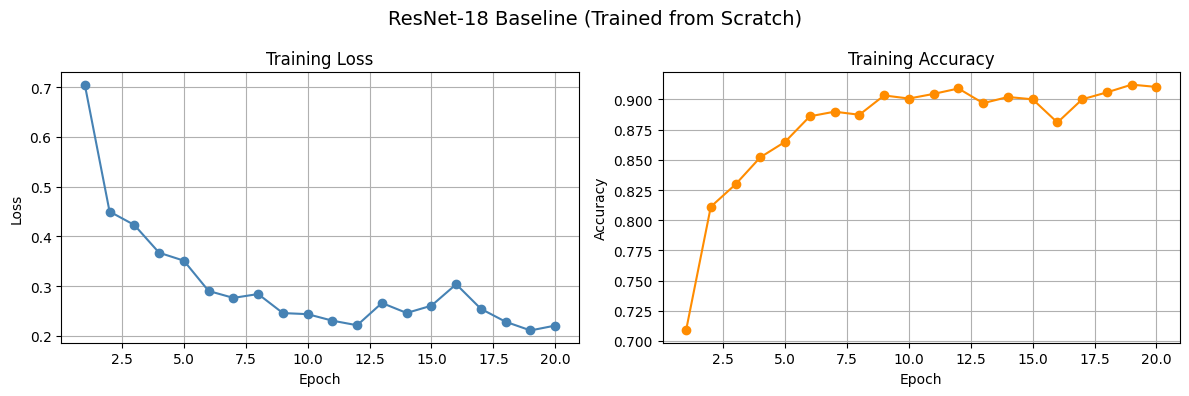

Saved


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, NUM_EPOCHS+1), train_losses, marker='o', color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(range(1, NUM_EPOCHS+1), train_accs, marker='o', color='darkorange')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)

plt.suptitle('ResNet-18 Baseline (Trained from Scratch)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/baseline_training_curves.png')
plt.show()
print('Saved')